In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [2]:
seed = 1332
np.random.seed(seed)

# Dataset Preprocessing

In [3]:
df = pd.read_csv('data/adult.data', header=None)

df.columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num', 
    'marital_status', 'occupation', 'relationship', 'race', 'sex', 
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Splitting the data

In [4]:
X, y = df.drop("income", axis=1), df["income"]
y = y.apply(lambda x: 1 if ">50K" in x else 0)

In [5]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=seed)

In [6]:
X_train.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
29960,36,Private,172538,Masters,14,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States
12854,49,Private,177211,Bachelors,13,Married-civ-spouse,Other-service,Husband,White,Male,0,0,40,United-States
22351,33,Local-gov,293063,Bachelors,13,Married-spouse-absent,Prof-specialty,Other-relative,Black,Male,0,0,40,?
2837,69,Self-emp-not-inc,69306,Some-college,10,Married-civ-spouse,Other-service,Wife,White,Female,0,0,15,United-States
26168,29,Private,152951,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States


### Checking Data Distribution

In [7]:
encoding_labels = [
    'workclass', 'education', 'marital_status', 'occupation', 
    'relationship', 'race', 'sex', 'native_country'
]

In [8]:
attributes_to_scale = list(
    set(X_train.columns).difference(set(X_train.columns).intersection(encoding_labels))
)

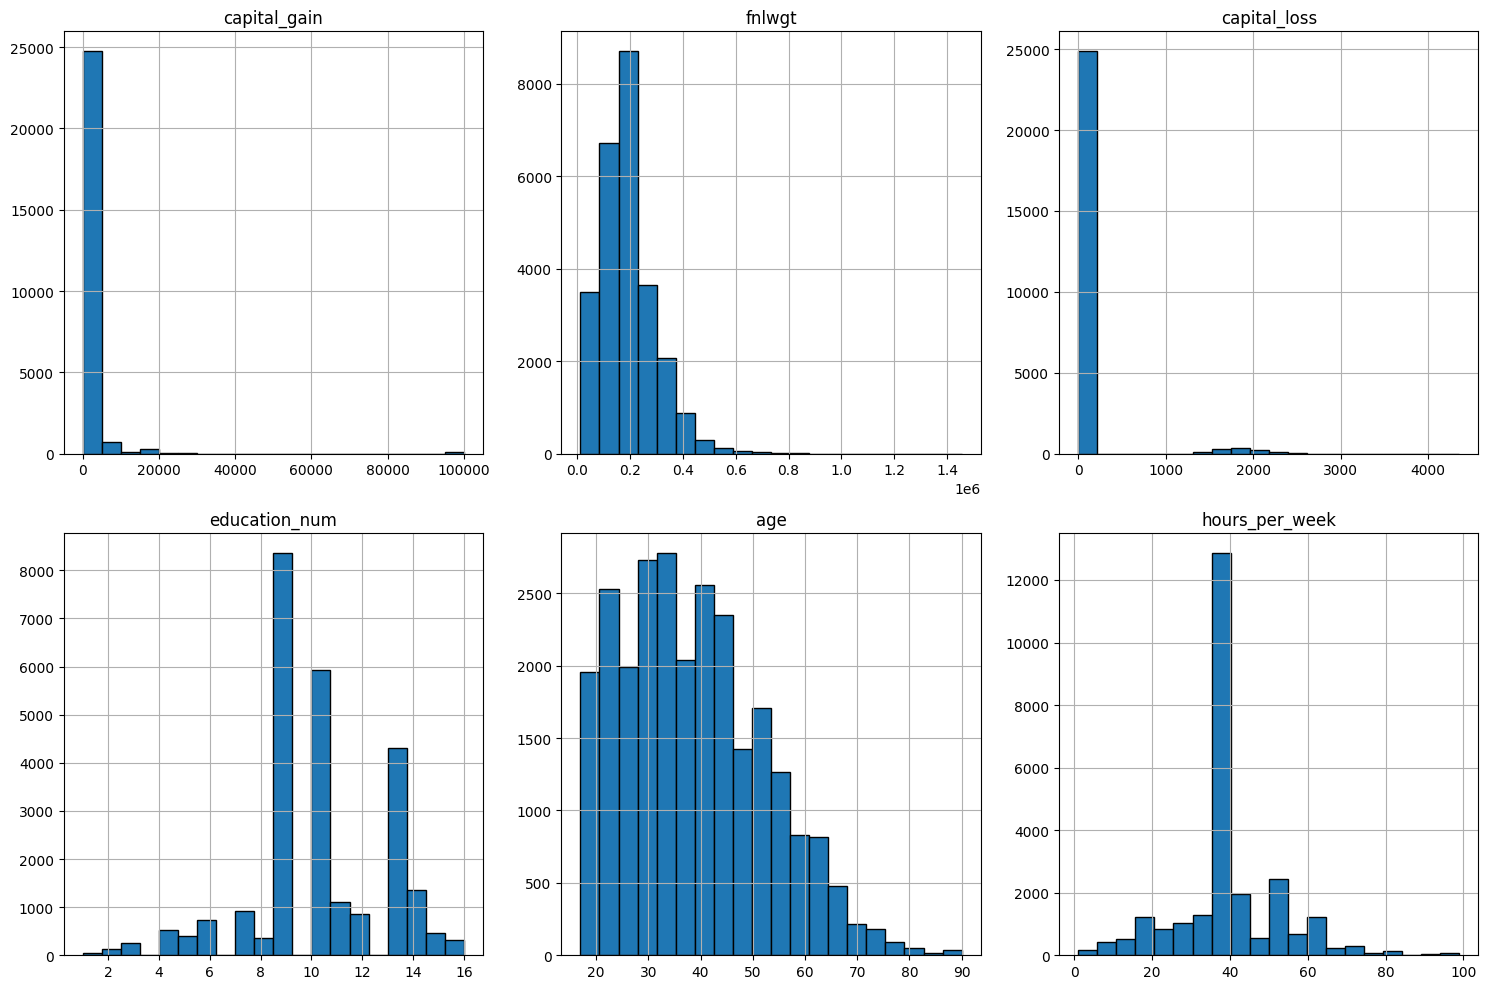

In [9]:
X_train[attributes_to_scale].hist(bins=20, figsize=(15, 10), layout=(-1, 3), edgecolor="black")
plt.tight_layout()
plt.show()

### Removing Extreme Outliers (>0.99)

In [10]:
# def IQR(df, cols):
#     mask = pd.Series(True, index=df.index)

#     for col in cols:
#         if not np.issubdtype(df[col].dtype, np.number):
#             continue

#         q1 = df[col].quantile(0.01)
#         q3 = df[col].quantile(0.99)
#         iqr = q3 - q1

#         lower = q1 - 1.5 * iqr
#         upper = q3 + 1.5 * iqr

#         mask &= df[col].between(lower, upper) | df[col].isna()

#     return df.index[mask]

In [11]:
# train_indices = IQR(X_train, attributes_to_scale)
# X_train = X_train.loc[train_indices]
# y_train = y_train[train_indices]

# val_indices = IQR(X_val, attributes_to_scale)
# X_val = X_val.loc[val_indices]
# y_val = y_val[val_indices]

In [12]:
# X_train[attributes_to_scale].hist(bins=20, figsize=(15, 10), layout=(-1, 3), edgecolor="black")
# plt.tight_layout()
# plt.show()

# TASK 1

In [13]:
class Metrics:

    def __init__(self):
        self.cls_counts = None
        self.num_samples = None

    def precompute(self, labels):
        labels_arr = np.asarray(labels)
        self.num_samples = labels_arr.size

        if self.num_samples == 0:
            self.cls_counts = {}
            return

        _, counts = np.unique(labels_arr, return_counts=True)
        self.cls_counts = counts  

    def gini_index(self, labels):
        if len(labels) == 0:
            return 0.0

        self.precompute(labels)
        probs = self.cls_counts / self.num_samples
        return 1.0 - float(np.dot(probs, probs))

    def entropy(self, labels):
        if len(labels) == 0:
            return 0.0

        self.precompute(labels)
        probs = self.cls_counts / self.num_samples

        valid_probs = probs[probs > 0]
        return float(-np.sum(valid_probs * np.log2(valid_probs)))

    def misclassification_error(self, labels):
        if len(labels) == 0:
            return 0.0

        self.precompute(labels)
        max_prob = np.max(self.cls_counts) / self.num_samples
        return 1.0 - float(max_prob)

    def split_information(self, child_splits, total_samples):
        if total_samples == 0:
            return 0.0

        sizes = np.fromiter((len(c) for c in child_splits), dtype=np.int64)
        probs = sizes / total_samples
        valid_probs = probs[probs > 0]

        if valid_probs.size == 0:
            return 0.0

        return float(-np.sum(valid_probs * np.log2(valid_probs)))

    def gain_ratio(self, parent_labels, child_splits):
        total_samples = len(parent_labels)
        if total_samples == 0:
            return 0.0

        parent_entropy = self.entropy(parent_labels)

        valid_children = [c for c in child_splits if len(c) > 0]
        if not valid_children:
            return 0.0

        weighted_child_entropy = sum(
            (len(c) / total_samples) * self.entropy(c) for c in valid_children
        )

        info_gain = parent_entropy - weighted_child_entropy
        split_info = self.split_information(child_splits, total_samples)

        if split_info == 0:
            return 0.0

        return float(info_gain / split_info)

In [14]:
def split(train, test, metric="entropy", target_col=None):

    if hasattr(test, 'values'):
        y = test[target_col].values if target_col else test.values
    else:
        y = test

    metrics = Metrics()
    attribute_weighted_metric = {}
    attribute_split = {}

    for attribute in train.columns:

        if np.issubdtype(train[attribute].dtype, np.number):
            # Continuous attribute
            values = np.sort(np.unique(train[attribute]))
            thresholds = (values[:-1] + values[1:]) / 2

            splits = []
            for threshold in thresholds:
                left_idx = train[attribute] <= threshold
                right_idx = train[attribute] > threshold
                splits.append((left_idx, right_idx, threshold))

        else:
            # Categorical attribute
            classes = np.unique(train[attribute])

            splits = []
            for name in classes:
                left_idx = train[attribute] == name
                right_idx = train[attribute] != name
                splits.append((left_idx, right_idx, name))

        best_metric = -float("inf") if metric == "gain_ratio" else float("inf")
        best_split = None

        for left_idx, right_idx, split_value in splits:

            left_samples = left_idx.sum()
            right_samples = right_idx.sum()

            if left_samples == 0 or right_samples == 0:
                continue

            if metric == "entropy":
                metric_left = metrics.entropy(y[left_idx])
                metric_right = metrics.entropy(y[right_idx])
                
                score = (
                    (left_samples / len(train)) * metric_left
                    + (right_samples / len(train)) * metric_right
                )

            elif metric == "gini":
                metric_left = metrics.gini_index(y[left_idx])
                metric_right = metrics.gini_index(y[right_idx])
                
                score = (
                    (left_samples / len(train)) * metric_left
                    + (right_samples / len(train)) * metric_right
                )

            elif metric == "misclassification_error":
                metric_left = metrics.misclassification_error(y[left_idx])
                metric_right = metrics.misclassification_error(y[right_idx])
                
                score = (
                    (left_samples / len(train)) * metric_left
                    + (right_samples / len(train)) * metric_right
                )

            elif metric == "gain_ratio":
                # Construct binary feature split representation for Split Info computation
                feature_binary_split = np.where(left_idx, 0, 1)
                
                score = metrics.gain_ratio(
                    parent_labels=y,
                    child_splits=[y[left_idx], y[right_idx]],
                    feature_values=feature_binary_split
                )

            else:
                raise ValueError(f"Unknown metric: {metric}")

            if metric == "gain_ratio":
                if score > best_metric:
                    best_metric = score
                    best_split = split_value
            else:
                if score < best_metric:
                    best_metric = score
                    best_split = split_value

        attribute_weighted_metric[attribute] = best_metric
        attribute_split[attribute] = best_split

        print(f"{attribute}: best_{metric} = {best_metric:.4f}, split_value = {best_split}")

    return attribute_weighted_metric, attribute_split

In [15]:
class Node:

    def __init__(
        self,
        feature=None,
        threshold=None,
        is_continuous=True,
        children=None,
        value=None,
        default_value=None
    ):
        self.feature = feature            
        self.threshold = threshold        
        self.is_continuous = is_continuous  
        self.children = children or {}    
        self.value = value                
        self.default_value = default_value 

    def is_leaf_node(self):
        return self.value is not None


class DecisionTreeClassifier:

    def __init__(
        self,
        criterion="entropy",
        max_depth=10,
        min_samples_split=2
    ):
        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
        self.metrics = Metrics()

    def _impute_missing(self, column):
        if np.issubdtype(column.dtype, np.number):
            return column.median()
        else:
            mode_vals = column.mode()
            return mode_vals[0] if not mode_vals.empty else column.dropna().iloc[0]

    def _calculate_score(self, parent_y, child_splits):
        total_samples = len(parent_y)
        
        if self.criterion == "entropy":
            parent_imp = self.metrics.entropy(parent_y)
            child_imp = sum((len(c) / total_samples) * self.metrics.entropy(c) for c in child_splits)
            return parent_imp - child_imp

        elif self.criterion == "gini":
            parent_imp = self.metrics.gini_index(parent_y)
            child_imp = sum((len(c) / total_samples) * self.metrics.gini_index(c) for c in child_splits)
            return parent_imp - child_imp

        elif self.criterion == "misclassification_error":
            parent_imp = self.metrics.misclassification_error(parent_y)
            child_imp = sum((len(c) / total_samples) * self.metrics.misclassification_error(c) for c in child_splits)
            return parent_imp - child_imp

        elif self.criterion == "gain_ratio":
            return self.metrics.gain_ratio(parent_y, child_splits)

        else:
            raise ValueError(f"Unknown criterion: {self.criterion}")

    def _find_best_split(self, X, y):
        best_score = -float("inf")
        best_feature = None
        best_threshold = None
        best_is_continuous = True
        best_splits = None

        for attribute in sorted(X.columns):
            col = X[attribute].copy()
            
            if col.isnull().any():
                col = col.fillna(self._impute_missing(col))

            is_num = np.issubdtype(col.dtype, np.number)

            if is_num:
                valid_vals = col.dropna()
                values = np.sort(np.unique(valid_vals))
                thresholds = (values[:-1] + values[1:]) / 2

                for t in thresholds:
                    left_mask = col <= t
                    right_mask = col > t

                    if left_mask.sum() == 0 or right_mask.sum() == 0:
                        continue

                    child_splits = [y[left_mask], y[right_mask]]
                    score = self._calculate_score(y, child_splits)

                    if score > best_score:
                        best_score = score
                        best_feature = attribute
                        best_threshold = t
                        best_is_continuous = True
                        best_splits = {"<=": left_mask, ">": right_mask}

            else:
                categories = np.unique(col.dropna())
                if len(categories) <= 1:
                    continue

                split_masks = {c: (col == c) for c in categories}
                child_splits = [y[mask] for mask in split_masks.values()]

                score = self._calculate_score(y, child_splits)

                if score > best_score:
                    best_score = score
                    best_feature = attribute
                    best_threshold = None
                    best_is_continuous = False
                    best_splits = split_masks

        return best_feature, best_threshold, best_is_continuous, best_splits

    def _most_common_label(self, y):
        if len(y) == 0:
            return None
        values, counts = np.unique(y, return_counts=True)
        max_count = np.max(counts)
        candidates = values[counts == max_count]
        return sorted(candidates)[0]

    def _build_tree(self, X, y, depth=0):
        num_samples = len(y)
        unique_labels = np.unique(y)

        if depth >= self.max_depth or len(unique_labels) <= 1 or num_samples < self.min_samples_split:
            return Node(value=self._most_common_label(y))

        feat, threshold, is_cont, splits = self._find_best_split(X, y)

        if feat is None or splits is None:
            return Node(value=self._most_common_label(y))

        default_val = self._most_common_label(y)
        children = {}

        for key, mask in splits.items():
            if mask.sum() == 0:
                children[key] = Node(value=default_val)
            else:
                children[key] = self._build_tree(X[mask], y[mask], depth + 1)

        return Node(
            feature=feat,
            threshold=threshold,
            is_continuous=is_cont,
            children=children,
            default_value=default_val
        )

    def fit(self, X, y):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        y_arr = np.array(y)
        self.root = self._build_tree(X_df, y_arr)

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value

        val = x[node.feature]

        if pd.isnull(val):
            return node.default_value

        if node.is_continuous:
            branch = "<=" if val <= node.threshold else ">"
            if branch in node.children:
                return self._traverse_tree(x, node.children[branch])
        else:
            if val in node.children:
                return self._traverse_tree(x, node.children[val])

        return node.default_value

    def predict(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        return np.array([self._traverse_tree(row, self.root) for _, row in X_df.iterrows()])

    def print_tree(self, figsize=(20, 10)):
        if self.root is None:
            print("Tree has not been fitted yet!")
            return

        def _count_leaves(node):
            if node is None or node.is_leaf_node() or not node.children:
                return 1
            return sum(_count_leaves(child) for child in node.children.values())

        def _get_max_depth(node):
            if node is None or node.is_leaf_node() or not node.children:
                return 1
            return 1 + max(_get_max_depth(child) for child in node.children.values())

        total_leaves = _count_leaves(self.root)
        total_depth = _get_max_depth(self.root)

        fig, ax = plt.subplots(figsize=figsize)
        ax.axis("off")

        leaf_counter = 0

        def _plot_node(node, depth=1):
            nonlocal leaf_counter

            if node is None:
                return 0.0, 0.0

            y = 1.0 - (depth / (total_depth + 1))

            # --- LEAF NODE ---
            if node.is_leaf_node() or not node.children:
                x = (leaf_counter + 0.5) / total_leaves
                leaf_counter += 1

                label = f"Class: {node.value}"
                bbox_props = dict(boxstyle="round,pad=0.3", fc="#a1d99b", ec="green", lw=1.5)
                ax.text(x, y, label, ha="center", va="center", bbox=bbox_props, fontsize=8, fontweight="bold")
                return x, y

            # --- INTERNAL DECISION NODE ---
            child_coords = []
            for branch_key, child_node in node.children.items():
                cx, cy = _plot_node(child_node, depth + 1)
                child_coords.append((branch_key, child_node, cx, cy))


            x = sum(cx for _, _, cx, _ in child_coords) / len(child_coords)

            if node.is_continuous:
                label = f"{node.feature}\n<= {node.threshold:.2f}"
            else:
                label = f"{node.feature}"

            bbox_props = dict(boxstyle="square,pad=0.4", fc="#9ecae1", ec="#3182bd", lw=1.5)
            ax.text(x, y, label, ha="center", va="center", bbox=bbox_props, fontsize=8, fontweight="bold")

            for branch_key, child_node, cx, cy in child_coords:
                ax.plot([x, cx], [y - 0.02, cy + 0.02], color="black", lw=1.0, zorder=1)

                if node.is_continuous:
                    edge_label = "T" if branch_key == "<=" else "F"
                    edge_color = "darkgreen" if branch_key == "<=" else "darkred"
                else:
                    edge_label = str(branch_key)
                    if len(edge_label) > 8:
                        edge_label = edge_label[:6] + ".."
                    edge_color = "darkblue"

                x_mid = (x + cx) / 2
                y_mid = (y + cy) / 2
                ax.text(
                    x_mid,
                    y_mid,
                    edge_label,
                    color=edge_color,
                    fontsize=7,
                    fontweight="bold",
                    ha="center",
                    va="center",
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85),
                    zorder=2
                )

            return x, y

        _plot_node(self.root, depth=1)
        
        plt.title("Decision Tree Visualization", fontsize=14, fontweight="bold", pad=20)
        plt.tight_layout()
        plt.show()

#### Gini Metric

In [16]:
tree = DecisionTreeClassifier(criterion="gini", max_depth=5)
tree.fit(X_train, y_train)

In [17]:
preds = tree.predict(X_val)
print("\nPredictions:", preds)
accuracy_score(np.array(preds), y_val.values)


Predictions: [0 1 1 ... 0 0 1]


0.844925533548288

Learned Tree Structure:


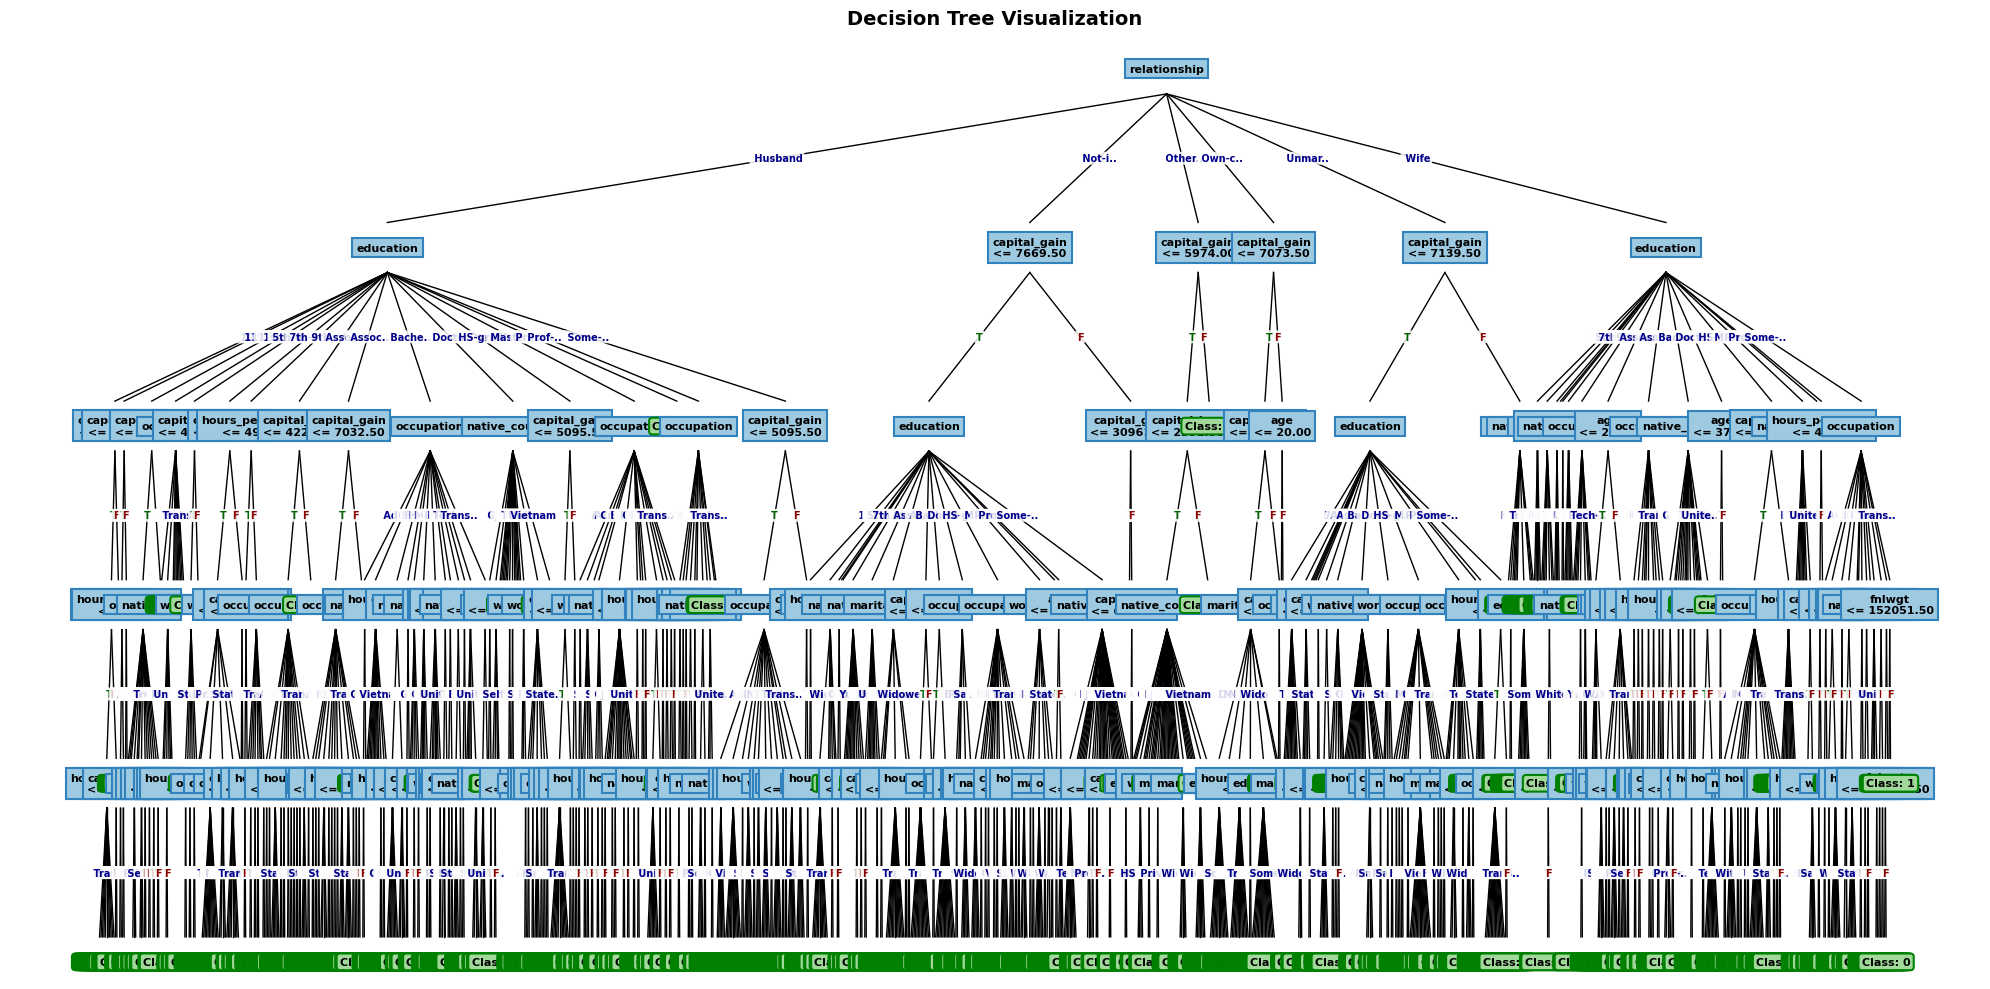

In [18]:
print("Learned Tree Structure:")
tree.print_tree(figsize=(20, 10))

#### Entropy Metric

In [19]:
tree = DecisionTreeClassifier(criterion="entropy", max_depth=5)
tree.fit(X_train, y_train)

In [20]:
preds = tree.predict(X_val)
print("\nPredictions:", preds)
accuracy_score(np.array(preds), y_val.values)


Predictions: [0 1 1 ... 0 0 1]


0.8404729003531399

Learned Tree Structure:


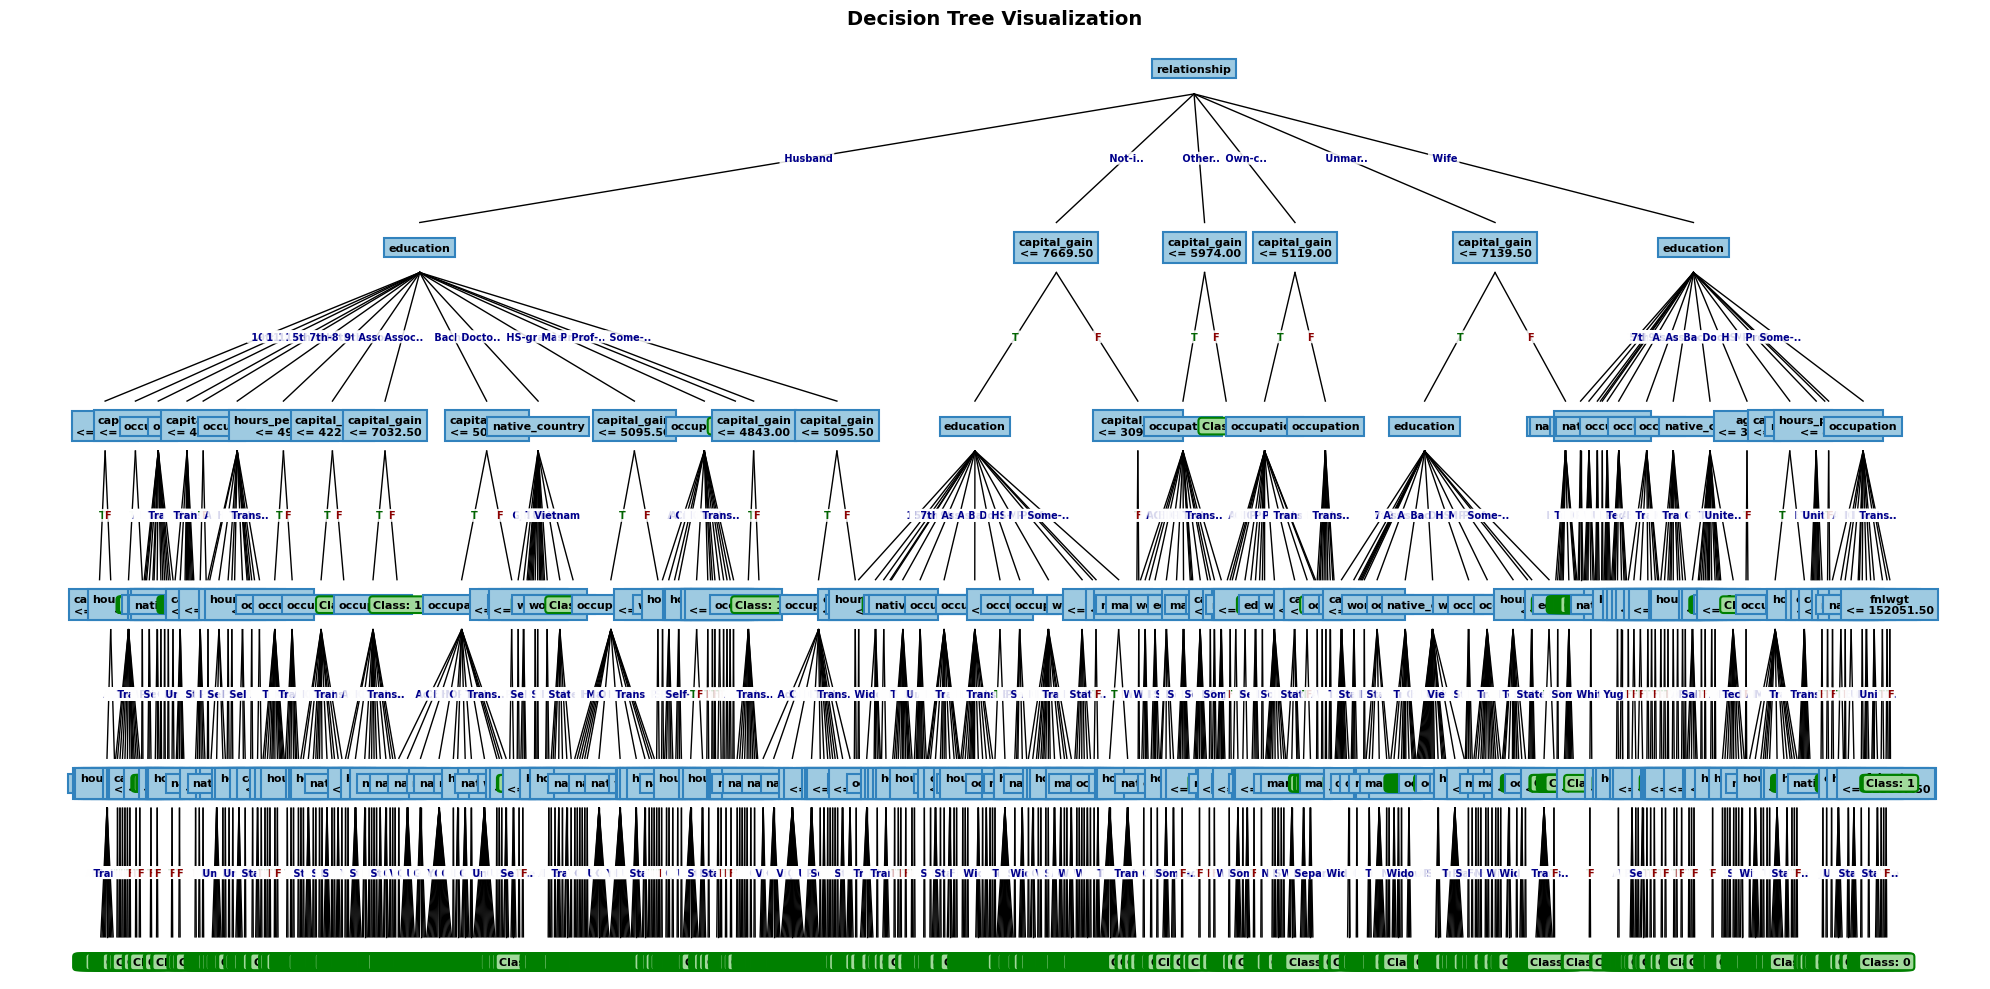

In [21]:
print("Learned Tree Structure:")
tree.print_tree(figsize=(20, 10))

#### Missclassification Error

In [22]:
tree = DecisionTreeClassifier(criterion="misclassification_error", max_depth=5)
tree.fit(X_train, y_train)

In [23]:
preds = tree.predict(X_val)
print("\nPredictions:", preds)
accuracy_score(np.array(preds), y_val.values)


Predictions: [0 0 1 ... 0 0 1]


0.8473821587594043

Learned Tree Structure:


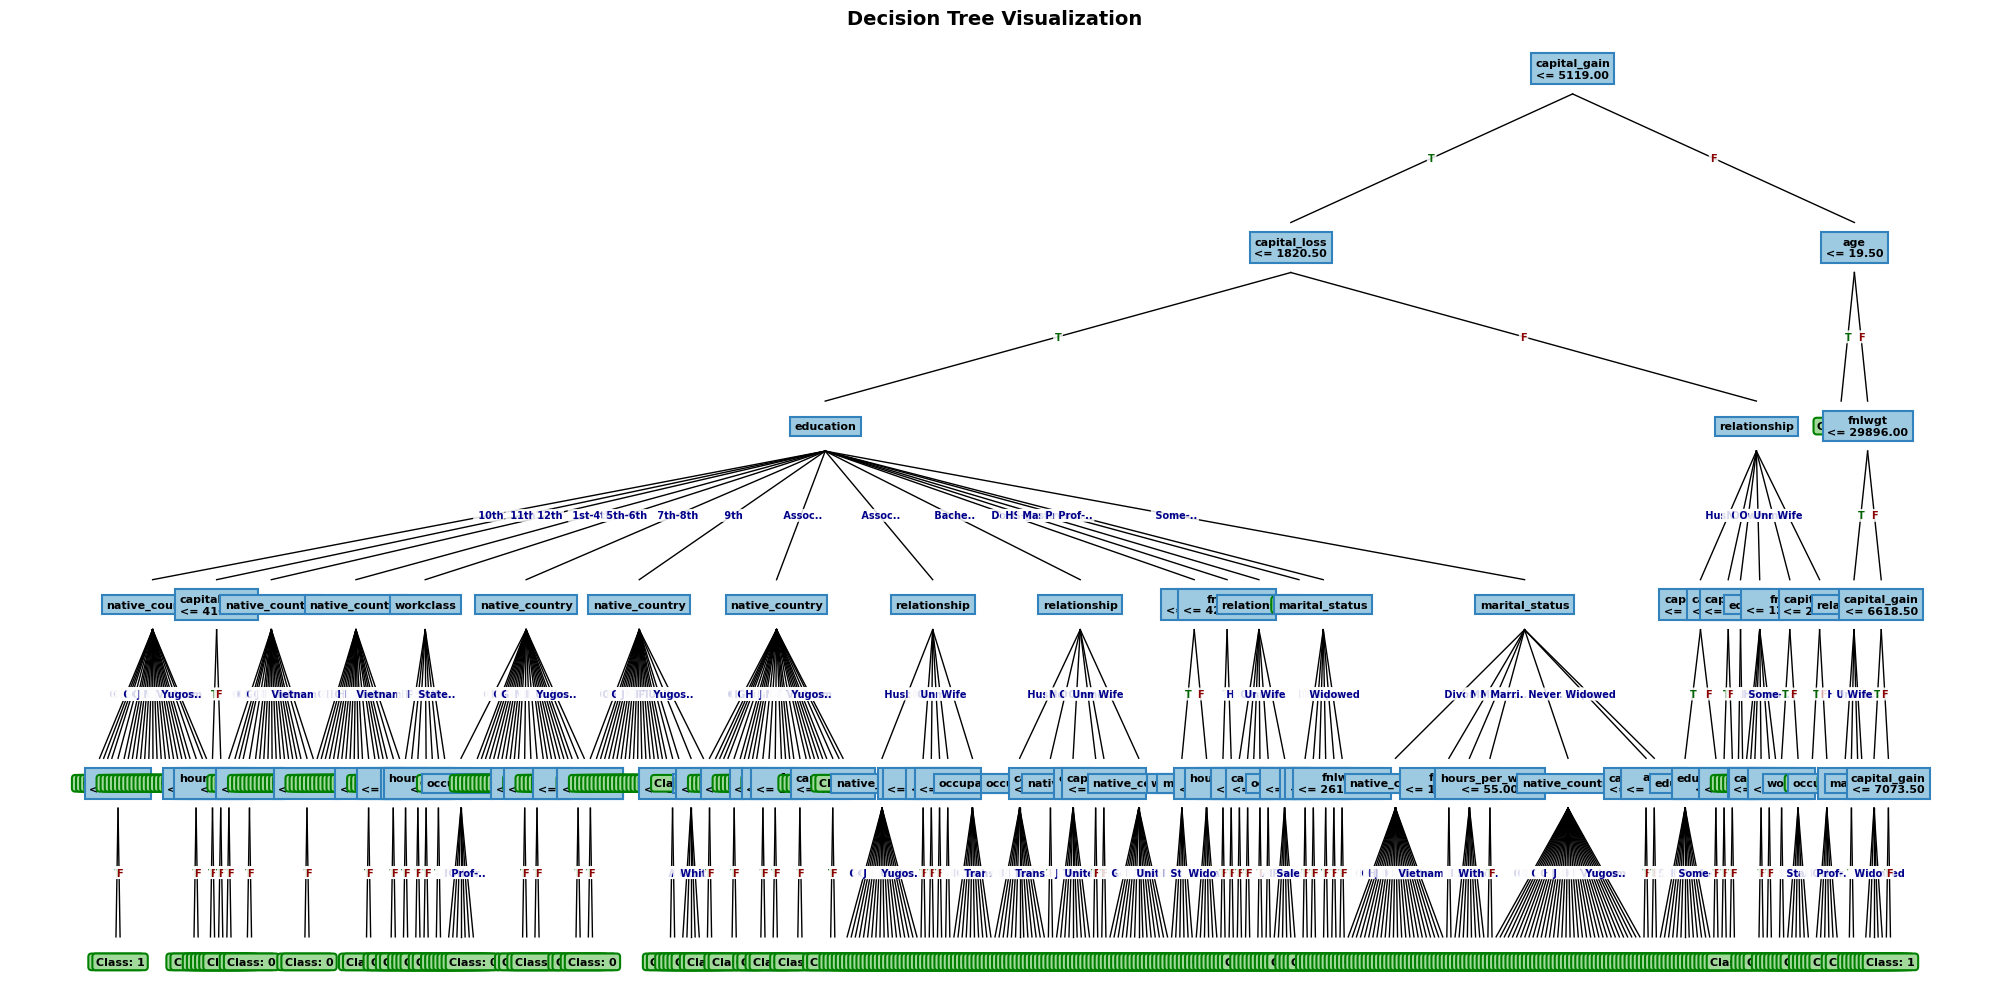

In [24]:
print("Learned Tree Structure:")
tree.print_tree(figsize=(20, 10))

#### Gain Ratio

In [25]:
tree = DecisionTreeClassifier(criterion="gain_ratio", max_depth=5)
tree.fit(X_train, y_train)

In [26]:
preds = tree.predict(X_val)
print("\nPredictions:", preds)
accuracy_score(np.array(preds), y_val.values)


Predictions: [0 0 0 ... 0 0 0]


0.8214340549669891

Learned Tree Structure:


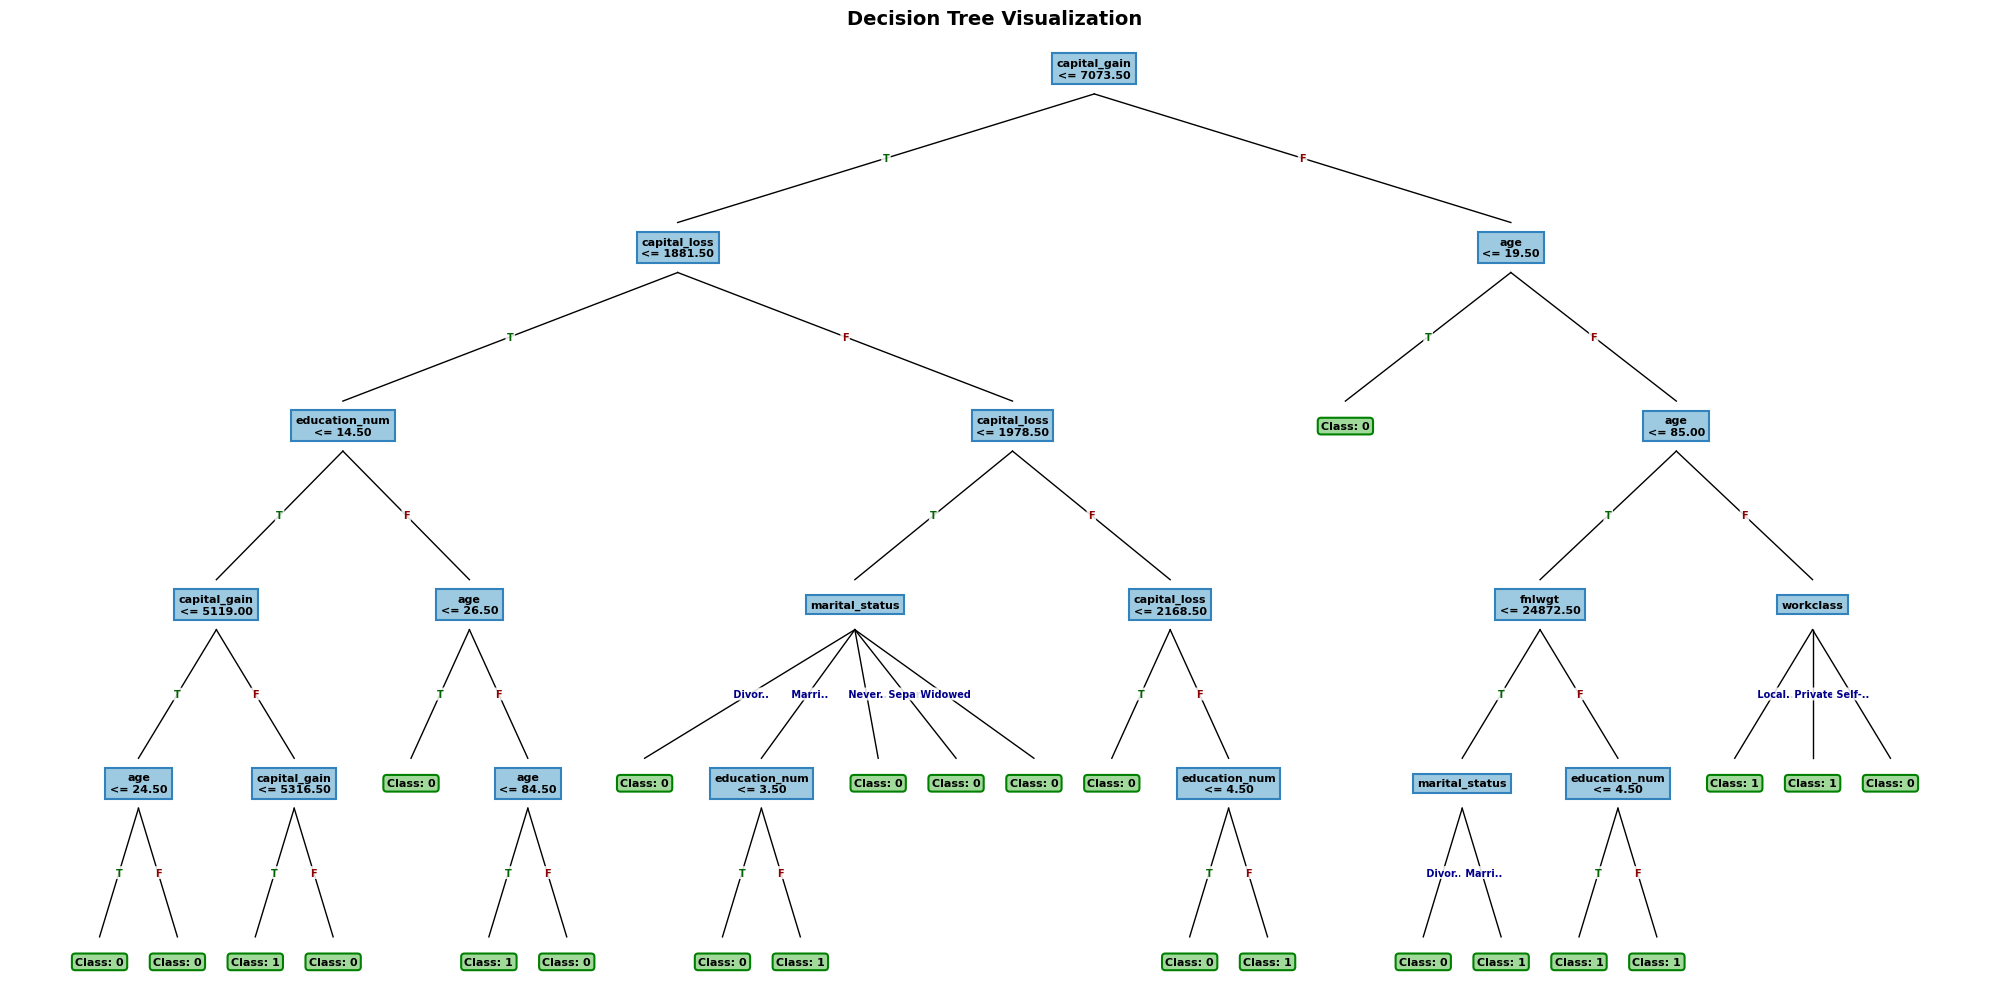

In [27]:
print("Learned Tree Structure:")
tree.print_tree(figsize=(20, 10))

# TASK 2:

In [28]:
import numpy as np
import pandas as pd

def evaluate_root_splits(X, y):
    metrics = Metrics()
    results = []

    parent_entropy = metrics.entropy(y)
    parent_gini = metrics.gini_index(y)
    parent_error = metrics.misclassification_error(y)
    total_samples = len(y)

    for attribute in sorted(X.columns):
        col = X[attribute].copy()
        
        # Handle missing values via median/mode imputation
        if col.isnull().any():
            if np.issubdtype(col.dtype, np.number):
                col = col.fillna(col.median())
            else:
                col = col.fillna(col.mode()[0])

        is_num = np.issubdtype(col.dtype, np.number)

        if is_num:
            # Candidate continuous threshold splits
            valid_vals = col.dropna()
            values = np.sort(np.unique(valid_vals))
            thresholds = (values[:-1] + values[1:]) / 2

            for t in thresholds:
                left_mask = col <= t
                right_mask = col > t

                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                child_splits = [y[left_mask], y[right_mask]]
                
                # Metric Calculations
                w_entropy = sum((len(c)/total_samples) * metrics.entropy(c) for c in child_splits)
                w_gini = sum((len(c)/total_samples) * metrics.gini_index(c) for c in child_splits)
                w_error = sum((len(c)/total_samples) * metrics.misclassification_error(c) for c in child_splits)
                
                ig = parent_entropy - w_entropy
                gini_red = parent_gini - w_gini
                error_red = parent_error - w_error
                gr = metrics.gain_ratio(y, child_splits)

                results.append({
                    'feature': attribute,
                    'split_type': 'continuous',
                    'split_detail': f'<= {t:.4f}',
                    'threshold': t,
                    'info_gain': ig,
                    'gini_reduction': gini_red,
                    'gain_ratio': gr,
                    'error_reduction': error_red
                })
        else:
            # Multiway split for categorical features
            categories = np.unique(col.dropna())
            if len(categories) <= 1:
                continue

            child_splits = [y[col == c] for c in categories]
            
            w_entropy = sum((len(c)/total_samples) * metrics.entropy(c) for c in child_splits)
            w_gini = sum((len(c)/total_samples) * metrics.gini_index(c) for c in child_splits)
            w_error = sum((len(c)/total_samples) * metrics.misclassification_error(c) for c in child_splits)

            ig = parent_entropy - w_entropy
            gini_red = parent_gini - w_gini
            error_red = parent_error - w_error
            gr = metrics.gain_ratio(y, child_splits)

            results.append({
                'feature': attribute,
                'split_type': 'categorical_multiway',
                'split_detail': f'Multiway ({len(categories)} categories)',
                'threshold': None,
                'info_gain': ig,
                'gini_reduction': gini_red,
                'gain_ratio': gr,
                'error_reduction': error_red
            })

    res_df = pd.DataFrame(results)

    print("==================================================")
    print("1. BEST SPLIT AT ROOT NODE BY CRITERION")
    print("==================================================")
    
    criteria_map = {
        'Gini Index Reduction': 'gini_reduction',
        'Information Gain': 'info_gain',
        'Gain Ratio': 'gain_ratio',
        'Misclassification Error Reduction': 'error_reduction'
    }

    for crit_name, col_name in criteria_map.items():
        best_row = res_df.sort_values(by=[col_name, 'feature'], ascending=[False, True]).iloc[0]
        print(f"• {crit_name}: Feature '{best_row['feature']}' ({best_row['split_detail']}) | Score: {best_row[col_name]:.4f}")

    return res_df


def compare_multiway_vs_binary(X, y, cat_feature):
    metrics = Metrics()
    col = X[cat_feature].copy().dropna()
    categories = np.unique(col)
    
    print("\n==================================================")
    print(f"3. MULTIWAY VS BINARY PARTITIONS FOR '{cat_feature}'")
    print("==================================================")

    child_multi = [y[col == c] for c in categories]
    ig_multi = metrics.entropy(y) - sum((len(c)/len(y)) * metrics.entropy(c) for c in child_multi)
    gr_multi = metrics.gain_ratio(y, child_multi)
    
    print(f"Multiway Split ({len(categories)} branches):")
    print(f"  Info Gain: {ig_multi:.4f} | Gain Ratio: {gr_multi:.4f}\n")

    print("Binary Partition Candidates:")
    from itertools import combinations
    
    n = len(categories)
    for r in range(1, (n // 2) + 1):
        for subset in combinations(categories, r):
            group1_mask = col.isin(subset)
            group2_mask = ~group1_mask
            
            child_binary = [y[group1_mask], y[group2_mask]]
            ig_bin = metrics.entropy(y) - sum((len(c)/len(y)) * metrics.entropy(c) for c in child_binary)
            gr_bin = metrics.gain_ratio(y, child_binary)

            set1_str = "{" + ", ".join(map(str, subset)) + "}"
            print(f"  Split {set1_str} vs Rest -> Info Gain: {ig_bin:.4f} | Gain Ratio: {gr_bin:.4f}")


def print_manual_calculation_example(parent_labels, child_splits, feature_name, split_label):
    metrics = Metrics()
    N = len(parent_labels)

    print("\n==================================================")
    print(f"4. CALCULATION FOR SPLIT: {feature_name} ({split_label})")
    print("==================================================")

    p_entropy = metrics.entropy(parent_labels)
    p_gini = metrics.gini_index(parent_labels)
    p_error = metrics.misclassification_error(parent_labels)

    print(f"Parent Node (N = {N}):")
    print(f"  Labels count: {dict(pd.Series(parent_labels).value_counts())}")
    print(f"  Parent Entropy = {p_entropy:.4f}")
    print(f"  Parent Gini = {p_gini:.4f}")
    print(f"  Parent Misclassification Error = {p_error:.4f}\n")

    w_entropy, w_gini, w_error = 0.0, 0.0, 0.0
    split_info = 0.0

    print("Child Nodes:")
    for idx, child in enumerate(child_splits):
        n_c = len(child)
        weight = n_c / N
        c_ent = metrics.entropy(child)
        c_gini = metrics.gini_index(child)
        c_err = metrics.misclassification_error(child)

        w_entropy += weight * c_ent
        w_gini += weight * c_gini
        w_error += weight * c_err
        if weight > 0:
            split_info -= weight * np.log2(weight)

        print(f"  Child {idx + 1} (n = {n_c}, weight = {weight:.4f}):")
        print(f"    Counts: {dict(pd.Series(child).value_counts())}")
        print(f"    Entropy: {c_ent:.4f} | Gini: {c_gini:.4f} | Error: {c_err:.4f}")

    print("\nFinal Split Metrics:")
    print(f"  1. Information Gain = {p_entropy:.4f} - {w_entropy:.4f} = {p_entropy - w_entropy:.4f}")
    print(f"  2. Split Information = {split_info:.4f}")
    print(f"  3. Gain Ratio = {(p_entropy - w_entropy) / split_info:.4f}" if split_info > 0 else "  3. Gain Ratio = 0.0")
    print(f"  4. Gini Reduction = {p_gini:.4f} - {w_gini:.4f} = {p_gini - w_gini:.4f}")
    print(f"  5. Misclassification Error Reduction = {p_error:.4f} - {w_error:.4f} = {p_error - w_error:.4f}")

In [29]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [30]:
res_df = evaluate_root_splits(X_train, y_train)
compare_multiway_vs_binary(X_train, y_train, cat_feature="marital_status") 

1. BEST SPLIT AT ROOT NODE BY CRITERION
• Gini Index Reduction: Feature 'relationship' (Multiway (6 categories)) | Score: 0.0742
• Information Gain: Feature 'relationship' (Multiway (6 categories)) | Score: 0.1643
• Gain Ratio: Feature 'capital_gain' (<= 7073.5000) | Score: 0.3420
• Misclassification Error Reduction: Feature 'capital_gain' (<= 5119.0000) | Score: 0.0431

3. MULTIWAY VS BINARY PARTITIONS FOR 'marital_status'
Multiway Split (7 branches):
  Info Gain: 0.1553 | Gain Ratio: 0.0850

Binary Partition Candidates:
  Split { Divorced} vs Rest -> Info Gain: 0.0131 | Gain Ratio: 0.0228
  Split { Married-AF-spouse} vs Rest -> Info Gain: 0.0000 | Gain Ratio: 0.0051
  Split { Married-civ-spouse} vs Rest -> Info Gain: 0.1510 | Gain Ratio: 0.1517
  Split { Married-spouse-absent} vs Rest -> Info Gain: 0.0015 | Gain Ratio: 0.0158
  Split { Never-married} vs Rest -> Info Gain: 0.0891 | Gain Ratio: 0.0975
  Split { Separated} vs Rest -> Info Gain: 0.0051 | Gain Ratio: 0.0257
  Split { Wido

In [31]:
sample_split = [y_train[X_train["age"] <= 30], y_train[X_train["age"] > 30]]
print_manual_calculation_example(y_train.values, sample_split, "age", "<= 30")


4. CALCULATION FOR SPLIT: age (<= 30)
Parent Node (N = 26048):
  Labels count: {0: 19828, 1: 6220}
  Parent Entropy = 0.7930
  Parent Gini = 0.3635
  Parent Misclassification Error = 0.2388

Child Nodes:
  Child 1 (n = 8514, weight = 0.3269):
    Counts: {0: 7974, 1: 540}
    Entropy: 0.3409 | Gini: 0.1188 | Error: 0.0634
  Child 2 (n = 17534, weight = 0.6731):
    Counts: {0: 11854, 1: 5680}
    Entropy: 0.9086 | Gini: 0.4380 | Error: 0.3239

Final Split Metrics:
  1. Information Gain = 0.7930 - 0.7231 = 0.0700
  2. Split Information = 0.9117
  3. Gain Ratio = 0.0767
  4. Gini Reduction = 0.3635 - 0.3337 = 0.0299
  5. Misclassification Error Reduction = 0.2388 - 0.2388 = -0.0000


# Task 3:

In [32]:
import numpy as np
import pandas as pd

def run_task_3_experiment(X_train, y_train, X_val, y_val):
    # 1. Add artificial UniqueID feature
    X_train_trap = X_train.copy()
    X_val_trap = X_val.copy()

    X_train_trap['UniqueID'] = [f"ID_{i}" for i in range(len(X_train_trap))]
    X_val_trap['UniqueID'] = [f"ID_{i}" for i in range(len(X_train_trap), len(X_train_trap) + len(X_val_trap))]

    print("==================================================")
    print("TASK 3: INFORMATION GAIN EXPERIMENT")
    print("==================================================")

    for criterion in ["entropy", "gain_ratio"]:
        tree = DecisionTreeClassifier(criterion=criterion, max_depth=10)
        tree.fit(X_train_trap, y_train)

        train_acc = (tree.predict(X_train_trap) == y_train).mean() * 100
        val_acc = (tree.predict(X_val_trap) == y_val).mean() * 100

        print(f"\nCriterion: {criterion.upper()}")
        print(f"Root Split Feature: {tree.root.feature}")
        print(f"Training Accuracy:   {train_acc:.2f}%")
        print(f"Validation Accuracy: {val_acc:.2f}%")

In [33]:
run_task_3_experiment(X_train, y_train, X_val, y_val)

TASK 3: INFORMATION GAIN EXPERIMENT

Criterion: ENTROPY
Root Split Feature: UniqueID
Training Accuracy:   100.00%
Validation Accuracy: 75.11%

Criterion: GAIN_RATIO
Root Split Feature: capital_gain
Training Accuracy:   87.01%
Validation Accuracy: 84.83%


# Task 4:

In [34]:
def count_total_nodes(node):
    if node is None:
        return 0
    if node.is_leaf_node() or not node.children:
        return 1
    return 1 + sum(count_total_nodes(child) for child in node.children.values())

def count_leaf_nodes(node):
    if node is None:
        return 0
    if node.is_leaf_node() or not node.children:
        return 1
    return sum(count_leaf_nodes(child) for child in node.children.values())

def get_actual_max_depth(node):
    if node is None:
        return 0
    if node.is_leaf_node() or not node.children:
        return 1
    return 1 + max(get_actual_max_depth(child) for child in node.children.values())


def add_label_noise(y, noise_rate=0.10):
    y_noisy = np.array(y).copy()
    
    unique_classes = np.unique(y_noisy)
    if len(unique_classes) != 2:
        raise ValueError("Label flipping helper assumes binary classification.")

    n_samples = len(y_noisy)
    n_flip = int(noise_rate * n_samples)
    
    flip_indices = np.random.choice(n_samples, size=n_flip, replace=False)
    
    c0, c1 = unique_classes[0], unique_classes[1]
    y_noisy[flip_indices] = np.where(y_noisy[flip_indices] == c0, c1, c0)
    
    return y_noisy


def run_depth_experiment(X_train, y_train, X_val, y_val, criterion="entropy"):
    depth_settings = [2, 4, 6, 8, 10, 15, None]  
    records = []

    for depth in depth_settings:
        print(f"Testing for depth: {depth}")
        tree = DecisionTreeClassifier(
            criterion=criterion,
            max_depth=depth if depth is not None else float("inf"),
            min_samples_split=2
        )
        tree.fit(X_train, y_train)

        train_preds = tree.predict(X_train)
        val_preds = tree.predict(X_val)

        train_acc = np.mean(train_preds == y_train) * 100
        val_acc = np.mean(val_preds == y_val) * 100

        total_nodes = count_total_nodes(tree.root)
        num_leaves = count_leaf_nodes(tree.root)
        actual_depth = get_actual_max_depth(tree.root)

        records.append({
            "max_depth_setting": "unlimited" if depth is None else str(depth),
            "train_acc": train_acc,
            "val_acc": val_acc,
            "total_nodes": total_nodes,
            "num_leaves": num_leaves,
            "actual_max_depth": actual_depth
        })

    return pd.DataFrame(records)


def run_task_4(X_train, y_train, X_val, y_val, criterion="entropy"): 
    print("Testing Clean Samples")   
    df_clean = run_depth_experiment(X_train, y_train, X_val, y_val, criterion=criterion)
    
    print("Testing Noisy Samples")   
    y_train_noisy = add_label_noise(y_train, noise_rate=0.10)
    df_noisy = run_depth_experiment(X_train, y_train_noisy, X_val, y_val, criterion=criterion)

    print("\n--- RESULTS: CLEAN TRAINING DATA ---")
    print(df_clean.to_markdown(index=False))

    print("\n--- RESULTS: 10% LABEL NOISE IN TRAINING DATA ---")
    print(df_noisy.to_markdown(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

    axes[0].plot(df_clean["num_leaves"], df_clean["train_acc"], marker='o', label="Train Accuracy", color="blue")
    axes[0].plot(df_clean["num_leaves"], df_clean["val_acc"], marker='s', label="Validation Accuracy", color="orange")
    axes[0].set_xscale("log")
    axes[0].set_xlabel("Tree Complexity (Number of Leaves - Log Scale)")
    axes[0].set_ylabel("Accuracy (%)")
    axes[0].set_title("Clean Training Data")
    axes[0].grid(True, linestyle="--", alpha=0.6)
    axes[0].legend()

    axes[1].plot(df_noisy["num_leaves"], df_noisy["train_acc"], marker='o', label="Train Accuracy (Noisy)", color="blue")
    axes[1].plot(df_noisy["num_leaves"], df_noisy["val_acc"], marker='s', label="Validation Accuracy", color="orange")
    axes[1].set_xscale("log")
    axes[1].set_xlabel("Tree Complexity (Number of Leaves - Log Scale)")
    axes[1].set_title("10% Corrupted Training Labels")
    axes[1].grid(True, linestyle="--", alpha=0.6)
    axes[1].legend()

    plt.suptitle(f"Task 4: Overfitting & Noise Analysis (Criterion: {criterion.upper()})", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

Testing Clean Samples
Testing for depth: 2
Testing for depth: 4
Testing for depth: 6
Testing for depth: 8
Testing for depth: 10
Testing for depth: 15
Testing for depth: None
Testing Noisy Samples
Testing for depth: 2
Testing for depth: 4
Testing for depth: 6
Testing for depth: 8
Testing for depth: 10
Testing for depth: 15
Testing for depth: None

--- RESULTS: CLEAN TRAINING DATA ---
| max_depth_setting   |   train_acc |   val_acc |   total_nodes |   num_leaves |   actual_max_depth |
|:--------------------|------------:|----------:|--------------:|-------------:|-------------------:|
| 2                   |     82.9776 |   82.7883 |            47 |           40 |                  3 |
| 4                   |     85.8223 |   84.4004 |           924 |          750 |                  5 |
| 6                   |     89.1662 |   83.2489 |          2822 |         2008 |                  7 |
| 8                   |     92.1146 |   82.6808 |          4392 |         2916 |                  9 |
| 

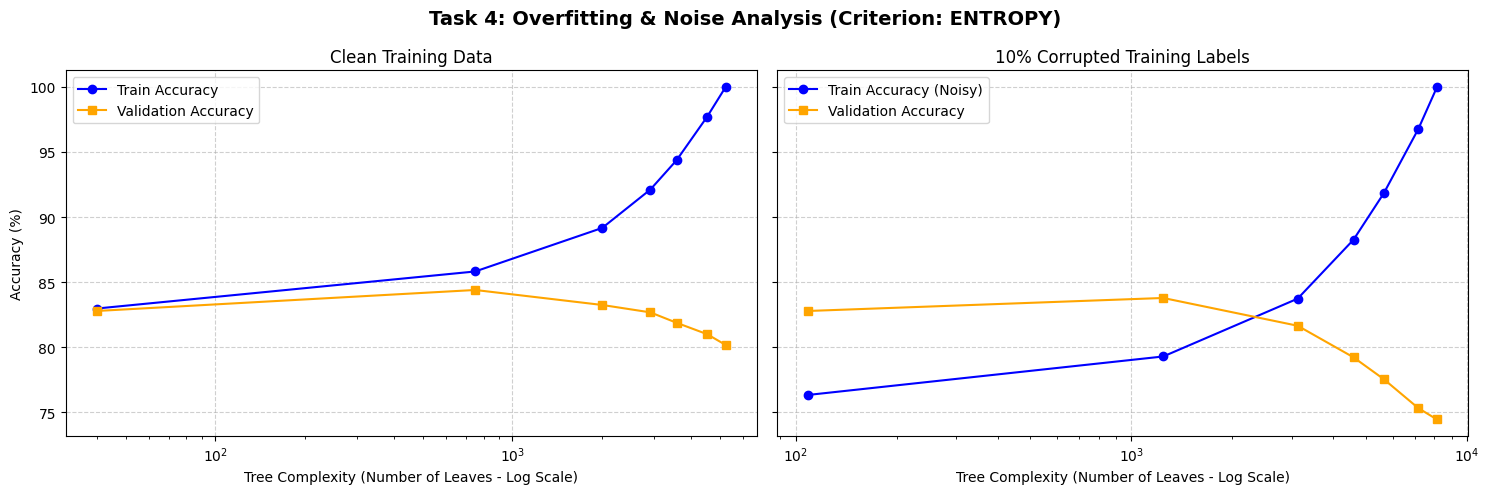

In [35]:
run_task_4(X_train, y_train, X_val, y_val, criterion="entropy")

# Task 5:

In [36]:
def compute_evaluation_metrics(y_true, y_pred, pos_label=">50K"):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    unique_labels = np.unique(np.concatenate([y_true, y_pred]))
    if pos_label not in unique_labels:
        pos_label = 1 if 1 in unique_labels else unique_labels[-1]

    neg_label = [lbl for lbl in unique_labels if lbl != pos_label][0]

    tp = np.sum((y_true == pos_label) & (y_pred == pos_label))
    fp = np.sum((y_true == neg_label) & (y_pred == pos_label))
    fn = np.sum((y_true == pos_label) & (y_pred == neg_label))
    tn = np.sum((y_true == neg_label) & (y_pred == neg_label))

    acc = (tp + tn) / len(y_true) if len(y_true) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (
        (2 * precision * recall) / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    conf_matrix = pd.DataFrame(
        [[tn, fp], [fn, tp]],
        index=[f"Actual {neg_label}", f"Actual {pos_label}"],
        columns=[f"Pred {neg_label}", f"Pred {pos_label}"],
    )

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": conf_matrix,
    }


def run_task_5(
    X_train, y_train, X_val, y_val, X_test, y_test, pos_label=">50K"
):

    criteria = ["entropy", "gain_ratio", "gini"]
    depth_candidates = [2, 4, 6, 8, 10, 12, 15]

    best_val_score = -1.0
    best_config = None

    print("\nEvaluating hyperparameters on Validation Set...")
    for crit in criteria:
        print(f"CRITERIA: {crit}")
        for depth in depth_candidates:
            print(f"Testing for depth: {depth}")
            tree = DecisionTreeClassifier(criterion=crit, max_depth=depth)
            tree.fit(X_train, y_train)

            val_preds = tree.predict(X_val)
            val_acc = np.mean(val_preds == y_val)

            if val_acc > best_val_score:
                best_val_score = val_acc
                best_config = (crit, depth)

    best_criterion, best_depth = best_config
    print(f"\nOptimal Hyperparameters Selected:")
    print(f"• Criterion: {best_criterion}")
    print(f"• Max Depth: {best_depth}")
    print(f"• Best Validation Accuracy: {best_val_score * 100:.2f}%")

    final_model = DecisionTreeClassifier(
        criterion=best_criterion, max_depth=best_depth
    )
    final_model.fit(X_train, y_train)

    test_preds = final_model.predict(X_test)

    metrics = compute_evaluation_metrics(
        y_test, test_preds, pos_label=pos_label
    )

    total_nodes = count_total_nodes(final_model.root)
    leaf_nodes = count_leaf_nodes(final_model.root)
    actual_depth = get_actual_max_depth(final_model.root)

    print("\n==================================================")
    print("TEST SET EVALUATION RESULTS (adult.test)")
    print("==================================================")
    print(f"• Accuracy:         {metrics['accuracy'] * 100:.2f}%")
    print(f"• Precision:        {metrics['precision']:.4f}")
    print(f"• Recall:           {metrics['recall']:.4f}")
    print(f"• F1-Score:         {metrics['f1_score']:.4f}")
    print("\n• Confusion Matrix:")
    print(metrics["confusion_matrix"].to_string())
    print("\n• Model Complexity Statistics:")
    print(f"  - Number of Nodes: {total_nodes}")
    print(f"  - Number of Leaves: {leaf_nodes}")
    print(f"  - Maximum Depth:   {actual_depth}")


In [37]:
run_task_5(X_train, y_train, X_val, y_val, X_val, y_val, pos_label=">50K")


Evaluating hyperparameters on Validation Set...
CRITERIA: entropy
Testing for depth: 2
Testing for depth: 4
Testing for depth: 6
Testing for depth: 8
Testing for depth: 10
Testing for depth: 12
Testing for depth: 15
CRITERIA: gain_ratio
Testing for depth: 2
Testing for depth: 4
Testing for depth: 6
Testing for depth: 8
Testing for depth: 10
Testing for depth: 12
Testing for depth: 15
CRITERIA: gini
Testing for depth: 2
Testing for depth: 4
Testing for depth: 6
Testing for depth: 8
Testing for depth: 10
Testing for depth: 12
Testing for depth: 15

Optimal Hyperparameters Selected:
• Criterion: gain_ratio
• Max Depth: 15
• Best Validation Accuracy: 85.17%

TEST SET EVALUATION RESULTS (adult.test)
• Accuracy:         85.17%
• Precision:        0.7773
• Recall:           0.5663
• F1-Score:         0.6552

• Confusion Matrix:
          Pred 0  Pred 1
Actual 0    4629     263
Actual 1     703     918

• Model Complexity Statistics:
  - Number of Nodes: 848
  - Number of Leaves: 508
  - Maxi